# Learning Latent Space with VAE
We will go through a simple VAE example, where VAE is used to learn the latent space of a chemical dataset.

## Retrieve dataset

In [10]:
!wget -O drug_activity.csv -q "https://github.com/SunLab-Rutgers/chem542_CDS/raw/main/labs/lab15/data/drug_activity.csv"

In [11]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

In [12]:
df = pd.read_csv("drug_activity.csv", index_col=False)
df.head()

,smiles,active,fingerprint
0,CCCc1cc(=O)oc2c3c(c4c(c12)OC(C)(C)CC4)OC(C)C(C...,1,0010010000100010100010001010011001011011001100...
1,Oc1ccc2ccccc2c1C1=NN2C(=S)NNC2=NN1,0,0000001110000010000000010001000001010101100000...
2,O=C(O)CN1CCN2CCCCCCCCN(CC1)CCN(CC(=O)O)CC2,0,0010110000100000000001000000001010000101000000...
3,Cl.NC1C2CN3CCC(O2)C13,0,0110000100100100100111010001001000000001100001...
4,Cc1nn(C(=O)Cc2ccccc2)c2c1C(c1ccc(O)cc1O)SC(=N)N2,1,0001010000110001010010000001110001111011001000...


### Extract the information

In [13]:
active_list = df["active"].to_list()
fps_list = df["fingerprint"].to_list()

In [14]:
# fingerprints are strings of 0 and 1, we turn them into numpy arrays
arr_list = []
for fp in fps_list:
    arr = np.array([int(b) for b in fp])
    arr_list.append(arr)
X_fps = np.array(arr_list, dtype=np.float32)
print("Input Data shape:", X_fps.shape)
print("Number of data: ", X_fps.shape[0])
print("Feature dimension: ", X_fps.shape[1])

Input Data shape: (2000, 128)
Number of data:  2000
Feature dimension:  128


In [15]:
# turn numpy array to pytorch tensor
dataset = TensorDataset(torch.tensor(X_fps))

# use DataLoader to divite dataset into batches
loader = DataLoader(dataset, batch_size=32, shuffle=True)

## Build VAE Model
We will build a VAE model to take the fingerprints as input, and learn the latent space of them.

In [16]:
fp_size = X_fps.shape[1]  # input feature dimension
latent_dim = 2  # small for visualization
hidden_dim = 64 # hidden layer for encoders and decoders

class VAE(nn.Module):
    def __init__(self, fp_size=128, latent_dim=2, hidden_dim=64):
        super().__init__()

        # encoder MLPs
        self.fc1 = nn.Linear(fp_size, hidden_dim) # input to hidden
        self.fc_mu = nn.Linear(hidden_dim, latent_dim) # hidden to output mu
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim) # hidden to output sigma

        # decoder MLPs
        self.fc2 = nn.Linear(latent_dim, hidden_dim) # latent z to hidden
        self.fc_out = nn.Linear(hidden_dim, fp_size) # hidden to reconstructed x

    # encoder
    def encode(self, x):
        h = torch.relu(self.fc1(x)) # activation function to hidden

        # output mu and log(sigma^2)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    # sample Z
    def sample_latent(self, mu, logvar):
        # sample the latent variable
        std = torch.exp(0.5 * logvar) # evaluate sigma
        eps = torch.randn_like(std) # noise
        return mu + eps * std # (eps.T).dot(std) -> matrix multiplication

    # decoder
    def decode(self, z):
        h = torch.relu(self.fc2(z)) # activation
        return torch.sigmoid(self.fc_out(h))  # fingerprints between 0 and 1, so use sigmoid

    def forward(self, x):
        # a forward pass stacks encoder, sampling z and decoder
        mu, logvar = self.encode(x)
        z = self.sample_latent(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

## Define the negative ELBO loss

In [17]:
def vae_loss(x, x_hat, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum') # cross entropy for the reconstruction term; per element loss is summed (reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) # KL divergence
    return recon_loss + kl_loss

## Start training

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

epochs = 500
for epoch in range(epochs):
    total_loss = 0
    for batch in loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss = vae_loss(x, x_hat, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataset):.4f}")

Epoch 1/500, Loss: 74.1218
Epoch 101/500, Loss: 61.8491
Epoch 201/500, Loss: 61.0791
Epoch 301/500, Loss: 60.5920
Epoch 401/500, Loss: 60.1198


## Visualize the latent space

In [19]:
model.eval()
with torch.no_grad():
    X_tensor = torch.tensor(X_fps).to(device)
    mu, logvar = model.encode(X_tensor)
    z = mu.cpu().numpy()  # use mean as latent representation


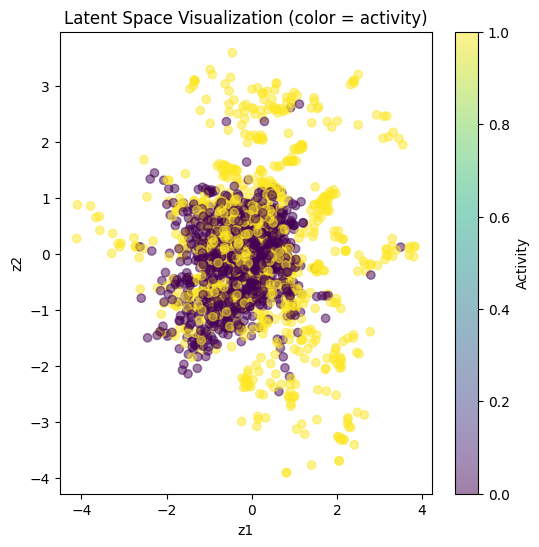

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(z[:,0], z[:,1], c=active_list, cmap='viridis', alpha=0.5)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent Space Visualization (color = activity)")
plt.colorbar(label="Activity")
plt.show()

## Finally, let's compare the latent space visualization to t-SNE

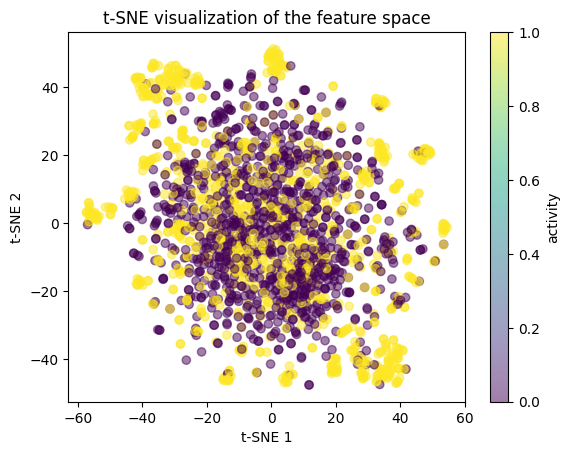

In [21]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2)
X_2d = tsne.fit_transform(X_fps)  # transform our input data

plt.scatter(X_2d[:,0], X_2d[:,1], c=active_list, cmap='viridis', alpha=0.5)
plt.colorbar(label='activity')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE visualization of the feature space')
plt.show()